<a href="https://colab.research.google.com/github/hmdaalln/image-denoising-capstone/blob/main/Image_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising

## Project Overview :
In this notebook, we prepare the SIDD dataset before training the image denoising model.
The goal is to understand the dataset structure and visualize noisy and clean images.

## Problem Statement

Image noise can reduce image quality and negatively affect many computer vision applications.

Our objective is to build a model that learns how to transform noisy images into clean images while keeping edges and textures as natural as possible.

## Project Objectives

The main objectives of this project are:

- Explore and understand the SIDD dataset.
- Prepare the dataset for training.
- Train a deep learning model for image denoising.
- Evaluate the model using PSNR and SSIM.
- Compare the model performance and visualize the results.

## Dataset Description

This project uses the Smartphone Image Denoising Dataset (SIDD).

The dataset contains pairs of noisy and clean images captured using different smartphones under various lighting conditions. It is specifically designed for image denoising tasks.

## Workflow

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 1. Import Libraries

In [16]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

## 2. Dataset Exploration

In this section, we explore the SIDD dataset to understand its structure and examine a sample pair of noisy and clean images before training the model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
# Extract the dataset
zip_path = "/content/drive/MyDrive/cap/SIDD_Small_sRGB_Only.zip"
extract_path = "/content/SIDD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [34]:
#Explore the dataset
# path to the dataset after extraction
dataset_path = "/content/SIDD/SIDD_Small_sRGB_Only/Data"

# each folder here represents one sample (a noisy/clean image pair)
image_folders = os.listdir(dataset_path)

print("Number of samples:", len(image_folders))
print("First sample folder:", image_folders[0])

Number of samples: 160
First sample folder: 0160_007_IP_00400_00400_3200_L


In [37]:
# Open the first scene
first_image = os.path.join(dataset_path, image_folders[1])

# Show the files inside the scene
files = os.listdir(first_image)

print("Files in the first sample:")
print(files)

Files in the first sample:
['NOISY_SRGB_010.PNG', 'GT_SRGB_010.PNG']


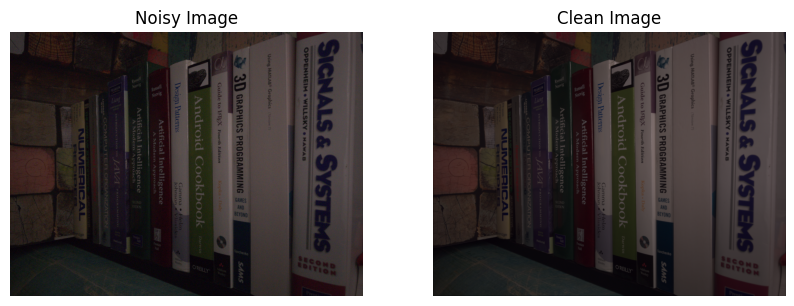

In [38]:
# Read the images
noisy_image = Image.open(os.path.join(first_image, "NOISY_SRGB_010.PNG"))
clean_image = Image.open(os.path.join(first_image, "GT_SRGB_010.PNG"))

# Display the images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy_image)
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clean_image)
plt.title("Clean Image")
plt.axis("off")

plt.show()

### Observation

The SIDD dataset contains pairs of noisy and clean images. Each noisy image has a corresponding clean image that will be used as the target during model training.

## 3. Data Preprocessing